# 14 — Rating Personality quadrant analysis & Mirror/Personality comparison plots

**Parts in this notebook**

| Part | Section |
|------|--------|
| Part 0 | Setup (imports, paths) |
| Part 1 | Quadrant classification (Rating Personality) |
| Part 2 | Load Rating Mirror results |
| Part 3 | Figure 1 — stacked bar (Mirror vs Personality + Rating Mirror only) |
| Part 4 | Figure 2 — mixed-sign ratio curve |
| Part 5 | Figure 3 — User 666 hidden activation scatter |
| Part 6 | User-level channel divergence across full cohort |
| Part 7 | Hidden Unit Attribution — Channel Divergence Drill-Down |
| Part 8 | User-Level Divergence Correlation Analysis |
| Part 9 | Sparsity-Controlled Divergence Analysis (raw vs residual) |


In [1]:
# Part 0 — Setup (imports, paths)
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"font.size": 12})

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

proc = root / "data" / "processed"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

QUAD_COLS = ["no_flip", "flip_both", "flip_delta1", "flip_delta2"]
QUAD_COLORS = {
    "no_flip": "#4C72B0",
    "flip_both": "#DD8452",
    "flip_delta1": "#55A868",
    "flip_delta2": "#C44E52",
}
LABELS = QUAD_COLS + ["zero"]
FIG_SIZE = (10, 6)

ModuleNotFoundError: No module named 'matplotlib'

## Part 1 — Quadrant classification (Rating Personality)

In [ ]:
# Part 1 — Quadrant classification (Rating Personality)
path_db1 = proc / "deltaWB1_per_epoch.npy"
path_db2 = proc / "deltaWB2_per_epoch.npy"
for p in (path_db1, path_db2):
    assert p.exists(), f"Missing {p} — run notebook 13 first."

deltaWB1 = np.load(path_db1)
deltaWB2 = np.load(path_db2)
assert deltaWB1.shape == deltaWB2.shape
n_epochs, n_visible, n_hidden = deltaWB1.shape
total_elements = n_visible * n_hidden


def classify_epoch(d1, d2):
    zero_mask = (d1 == 0.0) | (d2 == 0.0)
    s1 = np.sign(d1)
    s2 = np.sign(d2)
    active = ~zero_mask
    counts = {
        "no_flip": int(np.sum(active & (s1 > 0) & (s2 > 0))),
        "flip_both": int(np.sum(active & (s1 < 0) & (s2 < 0))),
        "flip_delta2": int(np.sum(active & (s1 > 0) & (s2 < 0))),
        "flip_delta1": int(np.sum(active & (s1 < 0) & (s2 > 0))),
        "zero": int(np.sum(zero_mask)),
    }
    counts["total"] = total_elements
    nz = total_elements - counts["zero"]
    counts["mixed_sign_ratio"] = (
        (counts["flip_delta1"] + counts["flip_delta2"]) / nz if nz > 0 else np.nan
    )
    return counts


freq_B = pd.DataFrame(
    [{"epoch": ep, **classify_epoch(deltaWB1[ep], deltaWB2[ep])} for ep in range(n_epochs)]
)

path_freq_B = proc / "quadrant_frequency_B.csv"
freq_B.to_csv(path_freq_B, index=False)
print(f"Saved: {path_freq_B}")

print("\n=== Rating Personality: mixed_sign_ratio ===")
for ep in (0, 25, 49):
    row = freq_B.loc[freq_B["epoch"] == ep].iloc[0]
    print(f"  epoch {ep:2d}: {row['mixed_sign_ratio']:.6f}")

Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data/processed/quadrant_frequency_B.csv

=== Rating Personality: mixed_sign_ratio ===
  epoch  0: 0.000381
  epoch 25: 0.452704
  epoch 49: 0.092988


## Part 2 — Load Rating Mirror results

In [ ]:
# Part 2 — Load Rating Mirror results
path_freq_A = proc / "quadrant_frequency.csv"
assert path_freq_A.exists(), f"Missing {path_freq_A} — run notebook 11 first."
freq_A = pd.read_csv(path_freq_A)
print(f"Loaded Rating Mirror: {len(freq_A)} epochs")
print(f"Loaded Rating Personality: {len(freq_B)} epochs")


def quad_proportions(df):
    """Per-epoch quadrant proportions excluding zeros."""
    out = df[["epoch"] + QUAD_COLS + ["zero", "total"]].copy()
    denom = out["total"] - out["zero"]
    for c in QUAD_COLS:
        out[f"prop_{c}"] = out[c] / denom
    return out


prop_A = quad_proportions(freq_A)
prop_B = quad_proportions(freq_B)
sample_epochs = list(range(0, n_epochs, 5))
if (n_epochs - 1) not in sample_epochs:
    sample_epochs.append(n_epochs - 1)

Loaded Rating Mirror: 50 epochs
Loaded Rating Personality: 50 epochs


## Part 3 — Figure 1: stacked bar (Mirror vs Personality) + Rating Mirror only

Exports:
- `outputs/quadrant_stacked_bar.png` — Mirror vs Personality side-by-side
- `outputs/quadrant_stacked_bar_A.png` — Rating Mirror only


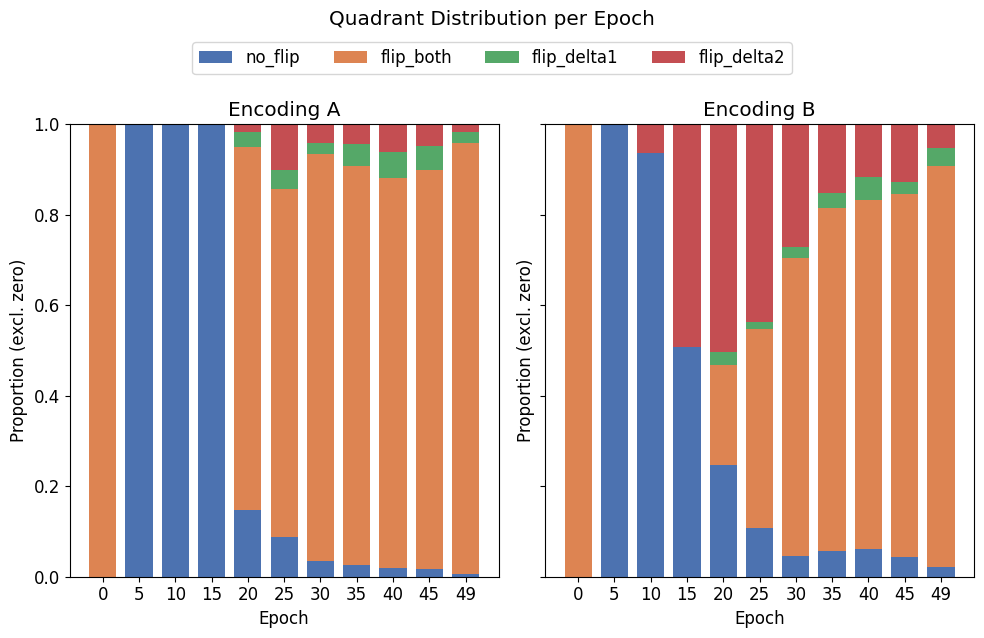

Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/quadrant_stacked_bar.png


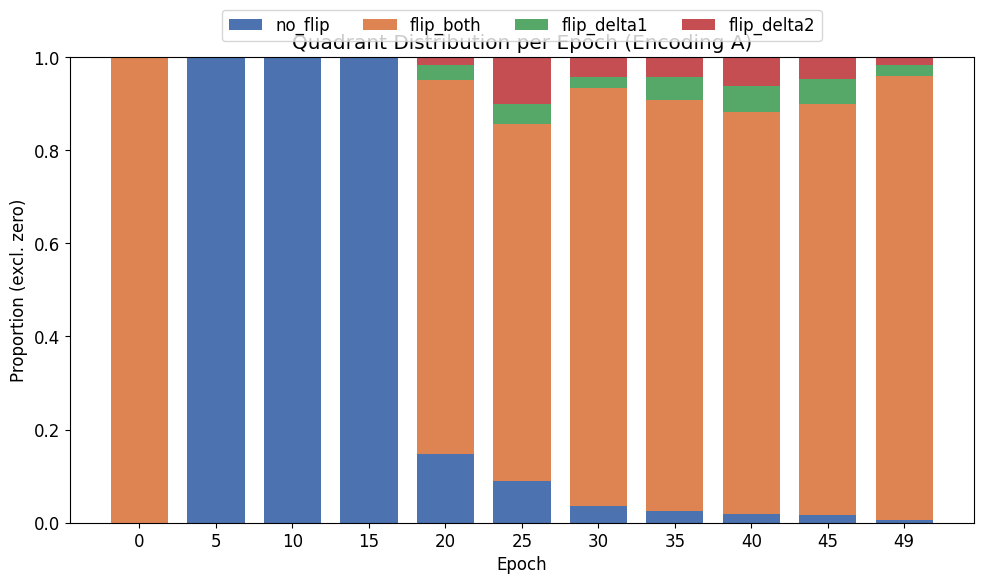

Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/quadrant_stacked_bar_A.png


In [ ]:
# Part 3 — Figure 1: stacked bar (Mirror vs Personality)
def plot_stacked_panel(ax, prop_df, title, epochs):
    sub = prop_df[prop_df["epoch"].isin(epochs)].sort_values("epoch")
    x = np.arange(len(sub))
    bottom = np.zeros(len(sub))
    for col in QUAD_COLS:
        vals = sub[f"prop_{col}"].values
        ax.bar(x, vals, bottom=bottom, width=0.75, label=col, color=QUAD_COLORS[col])
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(e)) for e in sub["epoch"].values])
    ax.set_ylim(0, 1)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Proportion (excl. zero)")
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE, sharey=True)
plot_stacked_panel(axes[0], prop_A, "Rating Mirror", sample_epochs)
plot_stacked_panel(axes[1], prop_B, "Rating Personality", sample_epochs)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Quadrant Distribution per Epoch", y=1.06)
plt.tight_layout()
path_fig1 = out_dir / "quadrant_stacked_bar.png"
fig.savefig(path_fig1, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {path_fig1}")

# Rating Mirror only (single panel)
fig_a, ax_a = plt.subplots(figsize=FIG_SIZE)
plot_stacked_panel(ax_a, prop_A, "Rating Mirror", sample_epochs)
handles_a, labels_a = ax_a.get_legend_handles_labels()
ax_a.legend(handles_a, labels_a, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.12))
ax_a.set_title("Quadrant Distribution per Epoch (Rating Mirror)")
plt.tight_layout()
path_fig1a = out_dir / "quadrant_stacked_bar_A.png"
fig_a.savefig(path_fig1a, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {path_fig1a}")


## Part 4 — Figure 2: mixed-sign ratio curve


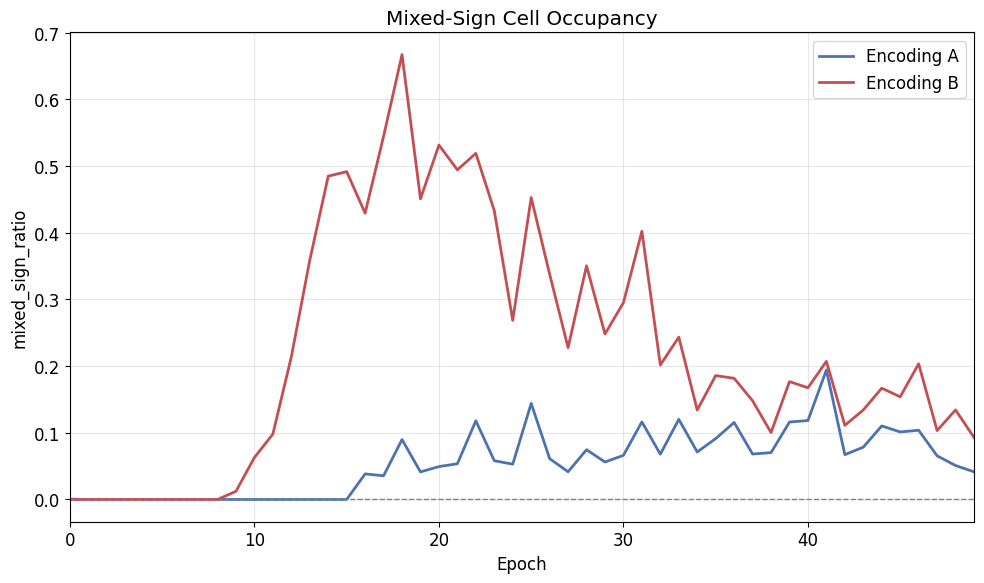

Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/mixed_sign_curve.png


In [ ]:
# Part 4 — Figure 2: mixed-sign ratio curve
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(freq_A["epoch"], freq_A["mixed_sign_ratio"], label="Rating Mirror", lw=2, color="#4C72B0")
ax.plot(freq_B["epoch"], freq_B["mixed_sign_ratio"], label="Rating Personality", lw=2, color="#C44E52")
ax.axhline(0, color="gray", linestyle="--", lw=1)
ax.set_xlabel("Epoch")
ax.set_ylabel("mixed_sign_ratio")
ax.set_title("Mixed-Sign Cell Occupancy")
ax.set_xlim(0, n_epochs - 1)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
path_fig2 = out_dir / "mixed_sign_curve.png"
fig.savefig(path_fig2, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {path_fig2}")

## Part 5 — Figure 3: User 666 hidden activation scatter (Rating Personality)


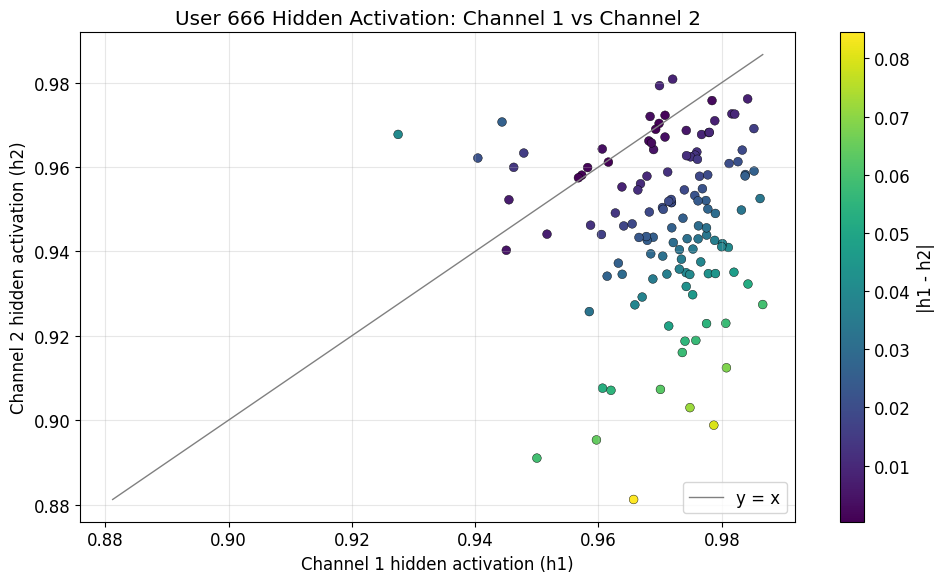

Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/user666_activation_scatter.png
User 666 row index: 0, mean |h1-h2|: 0.0264, max: 0.0845


In [ ]:
# Part 5 — Figure 3: User 666 hidden activation scatter
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


W1 = np.load(proc / "rbmB1_weights_final.npy")
W2 = np.load(proc / "rbmB2_weights_final.npy")
b1 = np.load(proc / "rbmB1_bias_hidden_final.npy")
b2 = np.load(proc / "rbmB2_bias_hidden_final.npy")
channelB1 = np.load(proc / "channelB1_softmax.npy")
channelB2 = np.load(proc / "channelB2_softmax.npy")
cohort_ids = np.load(proc / "cohort_user_ids.npy").astype(int)

uid = 666
assert uid in cohort_ids, "User 666 not in cohort"
row = int(np.where(cohort_ids == uid)[0][0])

v1 = channelB1[row].reshape(-1)
v2 = channelB2[row].reshape(-1)
h1 = sigmoid(v1 @ W1 + b1)
h2 = sigmoid(v2 @ W2 + b2)

dist = np.abs(h1 - h2)

fig, ax = plt.subplots(figsize=FIG_SIZE)
lo = float(min(h1.min(), h2.min()))
hi = float(max(h1.max(), h2.max()))
ax.plot([lo, hi], [lo, hi], color="gray", linestyle="-", lw=1, label="y = x")
sc = ax.scatter(h1, h2, c=dist, cmap="viridis", s=40, edgecolors="k", linewidths=0.3)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("|h1 - h2|")
ax.set_xlabel("Channel 1 hidden activation (h1)")
ax.set_ylabel("Channel 2 hidden activation (h2)")
ax.set_title("User 666 Hidden Activation: Channel 1 vs Channel 2")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
path_fig3 = out_dir / "user666_activation_scatter.png"
fig.savefig(path_fig3, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {path_fig3}")
print(f"User 666 row index: {row}, mean |h1-h2|: {dist.mean():.4f}, max: {dist.max():.4f}")

## Part 6 — User-level channel divergence across full cohort

For each cohort user, compute mean \(|h_1 - h_2|\) over 128 hidden units (Rating Personality RBMs).


User 666 rank (out of 51): 21  |  mean |h1-h2| = 0.026350

Top 5 (highest divergence):
 userId  mean_abs_divergence  rank
   4325             0.154991     1
   2637             0.137923     2
   8728             0.120090     3
   2144             0.096144     4
   8597             0.087607     5

Bottom 5 (lowest divergence):
 userId  mean_abs_divergence  rank
   8198             0.000811    47
   5458             0.000795    48
   7933             0.000532    49
   2768             0.000367    50
   9880             0.000298    51


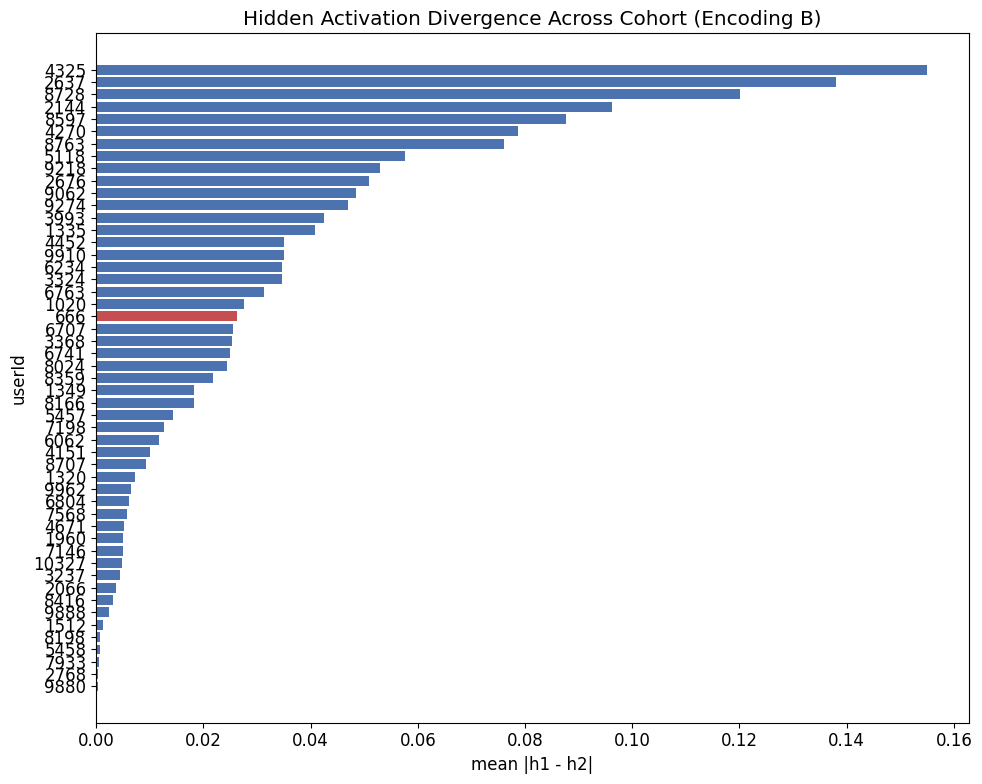


Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/cohort_divergence_bar.png


In [ ]:
# Part 6 — User-level channel divergence across full cohort
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


channelB1 = np.load(proc / "channelB1_softmax.npy")
channelB2 = np.load(proc / "channelB2_softmax.npy")
W1 = np.load(proc / "rbmB1_weights_final.npy")
W2 = np.load(proc / "rbmB2_weights_final.npy")
b1 = np.load(proc / "rbmB1_bias_hidden_final.npy")
b2 = np.load(proc / "rbmB2_bias_hidden_final.npy")
cohort_ids = np.load(proc / "cohort_user_ids.npy").astype(int)

n_users = len(cohort_ids)
divergence = np.zeros(n_users, dtype=np.float64)

for i in range(n_users):
    v1 = channelB1[i].reshape(-1)
    v2 = channelB2[i].reshape(-1)
    h1 = sigmoid(v1 @ W1 + b1)
    h2 = sigmoid(v2 @ W2 + b2)
    divergence[i] = float(np.mean(np.abs(h1 - h2)))

div_df = pd.DataFrame({"userId": cohort_ids, "mean_abs_divergence": divergence})
div_df = div_df.sort_values("mean_abs_divergence", ascending=False).reset_index(drop=True)
div_df["rank"] = np.arange(1, n_users + 1)

uid_highlight = 666
row_666 = div_df.loc[div_df["userId"] == uid_highlight].iloc[0]
print(f"User 666 rank (out of {n_users}): {int(row_666['rank'])}  |  "
      f"mean |h1-h2| = {row_666['mean_abs_divergence']:.6f}")

print("\nTop 5 (highest divergence):")
print(div_df.head(5).to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\nBottom 5 (lowest divergence):")
print(div_df.tail(5).to_string(index=False, float_format=lambda x: f"{x:.6f}"))

plot_df = div_df.sort_values("mean_abs_divergence", ascending=True)
colors = ["#C44E52" if u == uid_highlight else "#4C72B0" for u in plot_df["userId"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["userId"].astype(str), plot_df["mean_abs_divergence"], color=colors)
ax.set_xlabel("mean |h1 - h2|")
ax.set_ylabel("userId")
ax.set_title("Hidden Activation Divergence Across Cohort (Rating Personality)")
plt.tight_layout()
path_fig4 = out_dir / "cohort_divergence_bar.png"
fig.savefig(path_fig4, dpi=300, bbox_inches="tight")
plt.show()
print(f"\nSaved: {path_fig4}")

## Part 7 — Hidden Unit Attribution: Channel Divergence Drill-Down

For User 666, identify the hidden units with largest \(|h_1 - h_2|\), then inspect which movies each channel weights most heavily for those units (with metadata and tags). No interpretation — data only.


In [ ]:
# Part 7 — Hidden Unit Attribution: Channel Divergence Drill-Down
from collections import Counter

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


data_dir = root / "data"

W1 = np.load(proc / "rbmB1_weights_final.npy")
W2 = np.load(proc / "rbmB2_weights_final.npy")
b1 = np.load(proc / "rbmB1_bias_hidden_final.npy")
b2 = np.load(proc / "rbmB2_bias_hidden_final.npy")
channelB1 = np.load(proc / "channelB1_softmax.npy")
channelB2 = np.load(proc / "channelB2_softmax.npy")
cohort_ids = np.load(proc / "cohort_user_ids.npy").astype(int)
movie_vocab = np.load(proc / "movie_vocab.npy").astype(int)
n_movies = len(movie_vocab)

movies_df = pd.read_csv(data_dir / "movie.csv")
movie_meta = movies_df.set_index("movieId")[["title", "genres"]].to_dict("index")


def movie_importance(W, k):
    return np.abs(W[:, k].reshape(n_movies, 10)).sum(axis=1)


def top_movies_for_unit(W, k, n=10):
    scores = movie_importance(W, k)
    idx = np.argsort(scores)[::-1][:n]
    mids = movie_vocab[idx]
    return mids, scores[idx]


def top_tag_for_movie(mid, movie_tags):
    tags = movie_tags.get(int(mid), [])
    return tags[0] if tags else "(none)"


uid = 666
row = int(np.where(cohort_ids == uid)[0][0])
v1 = channelB1[row].reshape(-1)
v2 = channelB2[row].reshape(-1)
h1 = sigmoid(v1 @ W1 + b1)
h2 = sigmoid(v2 @ W2 + b2)
unit_diff = np.abs(h1 - h2)
top5_units = np.argsort(unit_diff)[::-1][:5]

print("=== Step A — Top 5 divergent hidden units (User 666) ===")
step_a = pd.DataFrame({
    "unit": top5_units,
    "h1": h1[top5_units],
    "h2": h2[top5_units],
    "abs_h1_minus_h2": unit_diff[top5_units],
})
print(step_a.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

needed_movie_ids = set()
for k in top5_units:
    mids1, _ = top_movies_for_unit(W1, k, n=10)
    mids2, _ = top_movies_for_unit(W2, k, n=10)
    needed_movie_ids.update(int(m) for m in mids1)
    needed_movie_ids.update(int(m) for m in mids2)

tags_df = pd.read_csv(data_dir / "tag.csv", usecols=["movieId", "tag"])
tags_df = tags_df[tags_df["movieId"].isin(needed_movie_ids)]
movie_tags = {}
for mid, grp in tags_df.groupby("movieId"):
    counts = Counter(t.strip().lower() for t in grp["tag"].dropna())
    movie_tags[int(mid)] = [t for t, _ in counts.most_common(5)]

print("\n=== Step B — Top-10 movies by weight importance (per unit, per channel) ===")
ch1_pool_ids = []
ch2_pool_ids = []
comparison_rows = []

for k in top5_units:
    print(f"\n--- Hidden unit {k} | h1={h1[k]:.6f} h2={h2[k]:.6f} |h1-h2|={unit_diff[k]:.6f} ---")
    for ch_name, W in [("Channel 1", W1), ("Channel 2", W2)]:
        mids, scores = top_movies_for_unit(W, k, n=10)
        if ch_name == "Channel 1":
            ch1_pool_ids.extend(int(m) for m in mids)
        else:
            ch2_pool_ids.extend(int(m) for m in mids)
        print(f"\n{ch_name}:")
        rows = []
        for mid, score in zip(mids, scores):
            meta = movie_meta.get(int(mid), {"title": "(missing)", "genres": "(missing)"})
            tag_list = movie_tags.get(int(mid), [])
            tag_str = ", ".join(tag_list) if tag_list else "(none)"
            rows.append({
                "movieId": int(mid),
                "title": meta["title"],
                "genres": meta["genres"],
                "importance": score,
                "top_5_tags": tag_str,
            })
            print(
                f"  movieId={int(mid):5d} | importance={score:.6f} | "
                f"{meta['title']} | {meta['genres']} | tags: {tag_str}"
            )
        if ch_name == "Channel 1":
            ch1_top5 = rows[:5]
        else:
            ch2_top5 = rows[:5]
    comparison_rows.append({
        "unit": k,
        "h1": h1[k],
        "h2": h2[k],
        "abs_diff": unit_diff[k],
        "ch1_top5": ch1_top5,
        "ch2_top5": ch2_top5,
    })

print("\n=== Step C — Side-by-side comparison (top-5 movies per channel) ===")
for row_data in comparison_rows:
    k = row_data["unit"]
    print(
        f"\nUnit {k} | h1={row_data['h1']:.6f} | h2={row_data['h2']:.6f} | "
        f"|h1-h2|={row_data['abs_diff']:.6f}"
    )
    print("  Channel 1 top-5:")
    for r in row_data["ch1_top5"]:
        print(
            f"    {r['title']} | {r['genres']} | top tag: "
            f"{top_tag_for_movie(r['movieId'], movie_tags)}"
        )
    print("  Channel 2 top-5:")
    for r in row_data["ch2_top5"]:
        print(
            f"    {r['title']} | {r['genres']} | top tag: "
            f"{top_tag_for_movie(r['movieId'], movie_tags)}"
        )

print("\n=== Step D — Genre frequency (top-10 movie pools, all 5 units) ===")

def genre_counts(movie_ids):
    c = Counter()
    for mid in movie_ids:
        genres = movie_meta.get(int(mid), {}).get("genres", "")
        if pd.isna(genres) or genres == "(no genres listed)":
            continue
        for g in str(genres).split("|"):
            g = g.strip()
            if g:
                c[g] += 1
    return c

gc1 = genre_counts(ch1_pool_ids)
gc2 = genre_counts(ch2_pool_ids)
all_genres = sorted(set(gc1) | set(gc2))
genre_table = pd.DataFrame({
    "genre": all_genres,
    "channel_1_count": [gc1.get(g, 0) for g in all_genres],
    "channel_2_count": [gc2.get(g, 0) for g in all_genres],
}).sort_values(["channel_1_count", "channel_2_count"], ascending=False)
print(genre_table.to_string(index=False))

=== Step A — Top 5 divergent hidden units (User 666) ===
 unit       h1       h2  abs_h1_minus_h2
   41 0.965697 0.881209         0.084488
   77 0.978700 0.898815         0.079885
   35 0.974831 0.902969         0.071863
   80 0.980748 0.912419         0.068329
   85 0.959668 0.895325         0.064343

=== Step B — Top-10 movies by weight importance (per unit, per channel) ===

--- Hidden unit 41 | h1=0.965697 h2=0.881209 |h1-h2|=0.084488 ---

Channel 1:
  movieId=  356 | importance=1.056719 | Forrest Gump (1994) | Comedy|Drama|Romance|War | tags: tom hanks, bittersweet, vietnam war, classic, inspirational
  movieId=  593 | importance=0.743260 | Silence of the Lambs, The (1991) | Crime|Horror|Thriller | tags: serial killer, psychology, anthony hopkins, cannibalism, jodie foster
  movieId=  318 | importance=0.728817 | Shawshank Redemption, The (1994) | Crime|Drama | tags: morgan freeman, prison, twist ending, stephen king, thought-provoking
  movieId=  110 | importance=0.619767 | Braveh

## Part 8 — User-Level Divergence Correlation Analysis

Test whether hidden activation divergence correlates with measurable user properties across all 51 cohort users (vocab movies only).


Streaming rating.csv for population means (vocab movies) …
Streaming rating.csv for cohort user ratings (vocab movies) …

=== Step C — Pearson correlations (divergence vs user properties) ===
  Contrarian degree     r=+0.0319  p=0.8239  (weak)
  Rating std            r=+0.0672  p=0.6394  (weak)
  Rating count          r=-0.4878  p=0.0002826  (moderate)
  Mean rating           r=-0.2026  p=0.154  (weak)


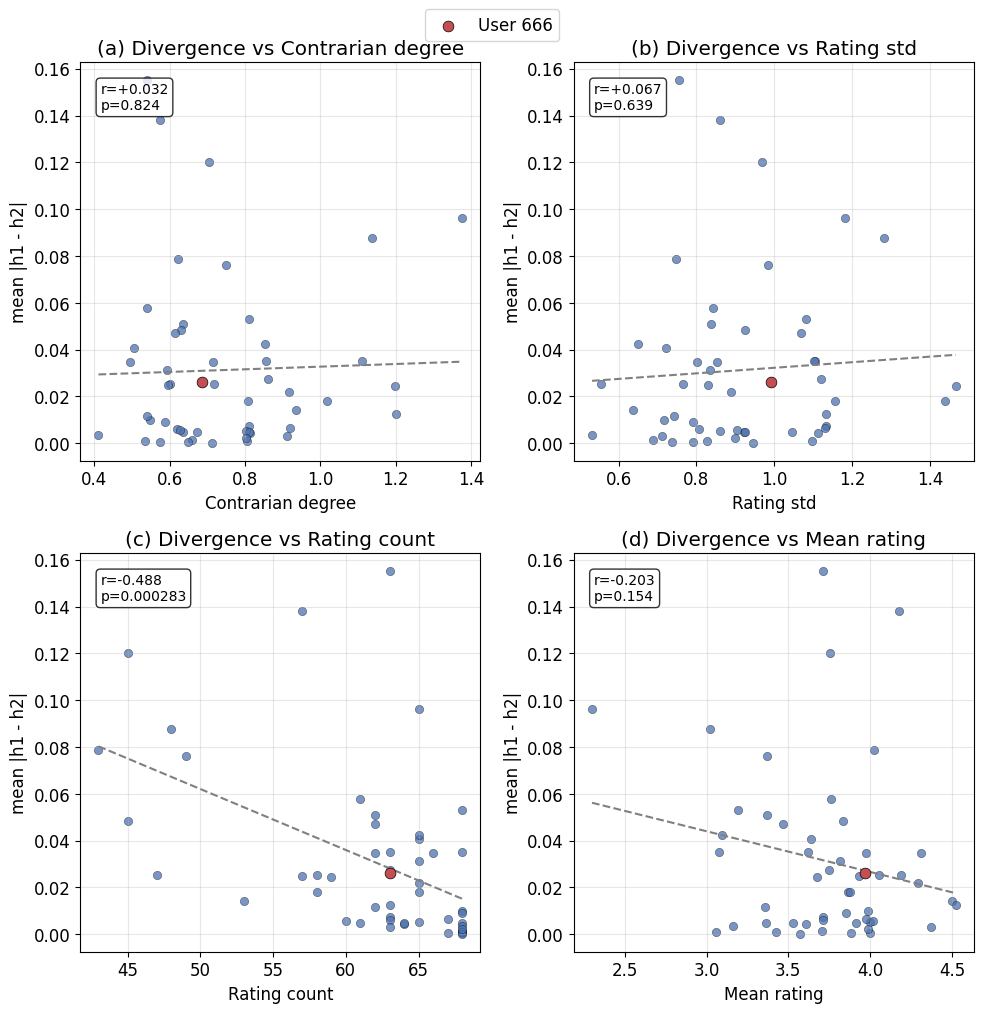


Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/divergence_correlations.png

=== Step E — Correlation summary ===
         Property Pearson r   p-value interpretation
Contrarian degree   +0.0319    0.8239           weak
       Rating std   +0.0672    0.6394           weak
     Rating count   -0.4878 0.0002826       moderate
      Mean rating   -0.2026     0.154           weak


In [ ]:
# Part 8 — User-Level Divergence Correlation Analysis
from collections import defaultdict

from scipy import stats

data_dir = root / "data"
rating_path = data_dir / "rating.csv"

cohort_ids = np.load(proc / "cohort_user_ids.npy").astype(int)
movie_vocab = np.load(proc / "movie_vocab.npy").astype(int)
vocab_set = set(movie_vocab.tolist())
cohort_set = set(cohort_ids.tolist())
uid_highlight = 666

# ── Step A: per-user properties (vocab movies only) ───────────────────────────
movie_sum = defaultdict(float)
movie_cnt = defaultdict(int)
print("Streaming rating.csv for population means (vocab movies) …")
for chunk in pd.read_csv(rating_path, usecols=["movieId", "rating"], chunksize=500_000):
    sub = chunk[chunk["movieId"].isin(vocab_set)]
    if sub.empty:
        continue
    grp = sub.groupby("movieId")["rating"]
    for mid, s in grp.sum().items():
        movie_sum[int(mid)] += float(s)
    for mid, c in grp.count().items():
        movie_cnt[int(mid)] += int(c)

pop_mean = {
    int(mid): movie_sum[mid] / movie_cnt[mid]
    for mid in movie_vocab
    if movie_cnt[mid] > 0
}

user_ratings = defaultdict(list)
user_contrarian_terms = defaultdict(list)
user_signed_terms = defaultdict(list)
print("Streaming rating.csv for cohort user ratings (vocab movies) …")
for chunk in pd.read_csv(
    rating_path, usecols=["userId", "movieId", "rating"], chunksize=500_000
):
    sub = chunk[chunk["userId"].isin(cohort_set) & chunk["movieId"].isin(vocab_set)]
    for uid, mid, rating in zip(
        sub["userId"].astype(int),
        sub["movieId"].astype(int),
        sub["rating"].astype(float),
    ):
        user_ratings[uid].append(rating)
        user_contrarian_terms[uid].append(abs(rating - pop_mean[mid]))
        user_signed_terms[uid].append(rating - pop_mean[mid])

user_rows = []
for uid in cohort_ids:
    uid = int(uid)
    rs = user_ratings[uid]
    user_rows.append({
        "userId": uid,
        "contrarian_degree": float(np.mean(user_contrarian_terms[uid])),  # mean |user - pop.|
        "contrarian_bias": float(np.mean(user_signed_terms[uid])),  # signed vs pop.: + generous, - strict
        "rating_std": float(np.std(rs, ddof=0)) if len(rs) > 1 else 0.0,
        "rating_count": len(rs),
        "mean_rating": float(np.mean(rs)),
    })
user_df = pd.DataFrame(user_rows)

# ── Step B: per-user divergence ───────────────────────────────────────────────
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


channelB1 = np.load(proc / "channelB1_softmax.npy")
channelB2 = np.load(proc / "channelB2_softmax.npy")
W1 = np.load(proc / "rbmB1_weights_final.npy")
W2 = np.load(proc / "rbmB2_weights_final.npy")
b1 = np.load(proc / "rbmB1_bias_hidden_final.npy")
b2 = np.load(proc / "rbmB2_bias_hidden_final.npy")

divergence = np.zeros(len(cohort_ids), dtype=np.float64)
for i in range(len(cohort_ids)):
    v1 = channelB1[i].reshape(-1)
    v2 = channelB2[i].reshape(-1)
    h1 = sigmoid(v1 @ W1 + b1)
    h2 = sigmoid(v2 @ W2 + b2)
    divergence[i] = float(np.mean(np.abs(h1 - h2)))

user_df["divergence"] = divergence

# ── Step C: Pearson correlations ──────────────────────────────────────────────
prop_cols = [
    ("contrarian_degree", "Contrarian degree"),
    ("rating_std", "Rating std"),
    ("rating_count", "Rating count"),
    ("mean_rating", "Mean rating"),
]

print("\n=== Step C — Pearson correlations (divergence vs user properties) ===")
corr_rows = []
for col, label in prop_cols:
    r, p = stats.pearsonr(user_df["divergence"], user_df[col])
    ar = abs(r)
    if ar > 0.5:
        interp = "strong"
    elif ar >= 0.3:
        interp = "moderate"
    else:
        interp = "weak"
    corr_rows.append({
        "Property": label,
        "Pearson r": r,
        "p-value": p,
        "interpretation": interp,
    })
    print(f"  {label:20s}  r={r:+.4f}  p={p:.4g}  ({interp})")

corr_df = pd.DataFrame(corr_rows)

# ── Step D: 2x2 scatter plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for ax, (col, label), plab in zip(axes.ravel(), prop_cols, panel_labels):
    x = user_df[col].values
    y = user_df["divergence"].values
    r, p = stats.pearsonr(x, y)

    mask_other = user_df["userId"] != uid_highlight
    ax.scatter(
        user_df.loc[mask_other, col],
        user_df.loc[mask_other, "divergence"],
        s=36,
        alpha=0.75,
        color="#4C72B0",
        edgecolors="k",
        linewidths=0.3,
    )
    ax.scatter(
        user_df.loc[~mask_other, col],
        user_df.loc[~mask_other, "divergence"],
        s=60,
        color="#C44E52",
        edgecolors="k",
        linewidths=0.5,
        zorder=5,
        label=f"User {uid_highlight}",
    )

    if len(x) > 1 and np.std(x) > 0:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color="gray", lw=1.5, ls="--")

    ax.set_xlabel(label)
    ax.set_ylabel("mean |h1 - h2|")
    ax.set_title(f"{plab} Divergence vs {label}")
    ax.text(
        0.05, 0.95,
        f"r={r:+.3f}\np={p:.3g}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    ax.grid(alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=1, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
path_fig = out_dir / "divergence_correlations.png"
fig.savefig(path_fig, dpi=300, bbox_inches="tight")
plt.show()
print(f"\nSaved: {path_fig}")

# ── Step E: summary table ─────────────────────────────────────────────────────
print("\n=== Step E — Correlation summary ===")
print(
    corr_df.to_string(
        index=False,
        formatters={
            "Pearson r": lambda x: f"{x:+.4f}",
            "p-value": lambda x: f"{x:.4g}",
        },
    )
)

=== Divergence vs contrarian bias (generous / strict vs population) ===
Pearson r (divergence vs |contrarian_bias|):      +0.1136  p=0.4275
Pearson r (divergence vs contrarian_bias (+ generous, - strict)): -0.2993  p=0.03288


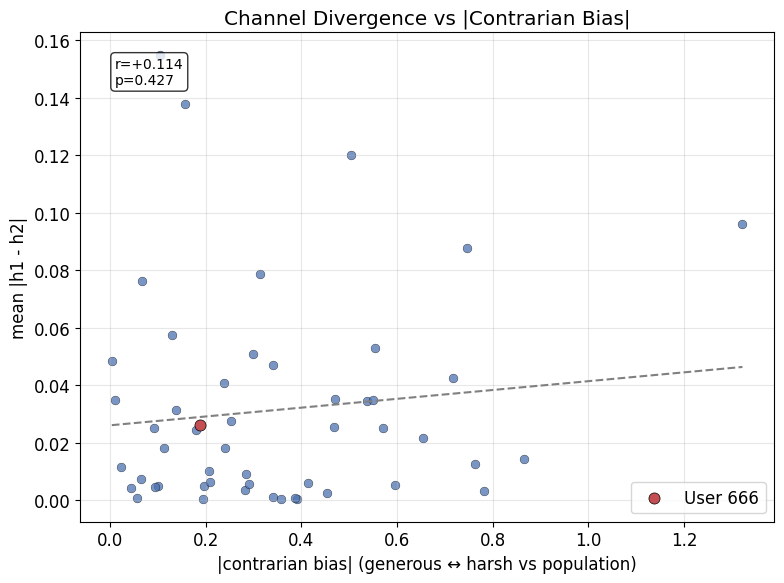

Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/divergence_vs_contrarian_bias.png


In [ ]:
# Part 8 — Channel divergence vs contrarian bias (generous / strict)
from scipy import stats

if "user_df" not in globals():
    raise RuntimeError("Run Part 8 (previous cell) first.")
if "contrarian_bias" not in user_df.columns:
    raise RuntimeError("Re-run Part 8 to compute per-user contrarian_bias.")

uid_highlight = 666
plot_df = user_df.copy()
plot_df["abs_contrarian_bias"] = plot_df["contrarian_bias"].abs()

r_abs, p_abs = stats.pearsonr(plot_df["abs_contrarian_bias"], plot_df["divergence"])
r_signed, p_signed = stats.pearsonr(plot_df["contrarian_bias"], plot_df["divergence"])

print("=== Divergence vs contrarian bias (generous / strict vs population) ===")
print(f"Pearson r (divergence vs |contrarian_bias|):      {r_abs:+.4f}  p={p_abs:.4g}")
print(f"Pearson r (divergence vs contrarian_bias (+ generous, - strict)): {r_signed:+.4f}  p={p_signed:.4g}")

x = plot_df["abs_contrarian_bias"].values
y = plot_df["divergence"].values

fig, ax = plt.subplots(figsize=(8, 6))
mask_other = plot_df["userId"] != uid_highlight
ax.scatter(
    plot_df.loc[mask_other, "abs_contrarian_bias"],
    plot_df.loc[mask_other, "divergence"],
    s=40,
    alpha=0.75,
    color="#4C72B0",
    edgecolors="k",
    linewidths=0.3,
)
ax.scatter(
    plot_df.loc[~mask_other, "abs_contrarian_bias"],
    plot_df.loc[~mask_other, "divergence"],
    s=64,
    color="#C44E52",
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
    label=f"User {uid_highlight}",
)

if len(x) > 1 and np.std(x) > 0:
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="gray", lw=1.5, ls="--")

ax.set_xlabel("|contrarian bias| (generous ↔ strict vs population)")
ax.set_ylabel("mean |h1 - h2|")
ax.set_title("Channel Divergence vs |Contrarian Bias|")
ax.text(
    0.05, 0.95,
    f"r={r_abs:+.3f}\np={p_abs:.3g}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
path_fig = out_dir / "divergence_vs_contrarian_bias.png"
fig.savefig(path_fig, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {path_fig}")

## Part 9 — Sparsity-Controlled Divergence Analysis

Requires **Part 8** (`user_df`).

**Formulas**
- `divergence(u) = mean(|h1 - h2|)` over hidden units
- `residual_divergence = divergence - (β₀ + β₁ × rating_count)` — linear effect of rating count removed

**Outputs**
- `outputs/divergence_raw.png` — raw scatter (no control)
- `outputs/divergence_controlled.png` — residual scatter (control rating count)


=== Step A — Partial correlations (control: rating_count) ===
  divergence vs contrarian_degree   partial r=+0.0011  p=0.9939
  divergence vs rating_std          partial r=+0.0465  p=0.7482

=== Step B — Divergence vs contrarian_degree within rating_count terciles ===
  low  band  count  43- 62  n=19  r=-0.0578  p=0.8141
  mid  band  count  63- 65  n=17  r=-0.0272  p=0.9174
  high band  count  66- 68  n=15  r=+0.3899  p=0.1508

=== Step C — Formulas & raw vs partial correlations ===
divergence(u) = mean(|h1 - h2|) over hidden units
residual_divergence = divergence - (-0.002606 * rating_count + +0.192347)

Raw Pearson r (no control):
  divergence vs contrarian_degree   r=+0.0319  p=0.8239
  divergence vs rating_std          r=+0.0672  p=0.6394
  divergence vs rating_count        r=-0.4878  p=0.0002826

User 666:
  divergence           = 0.0264
  residual_divergence  = -0.0018
  rating_count         = 63


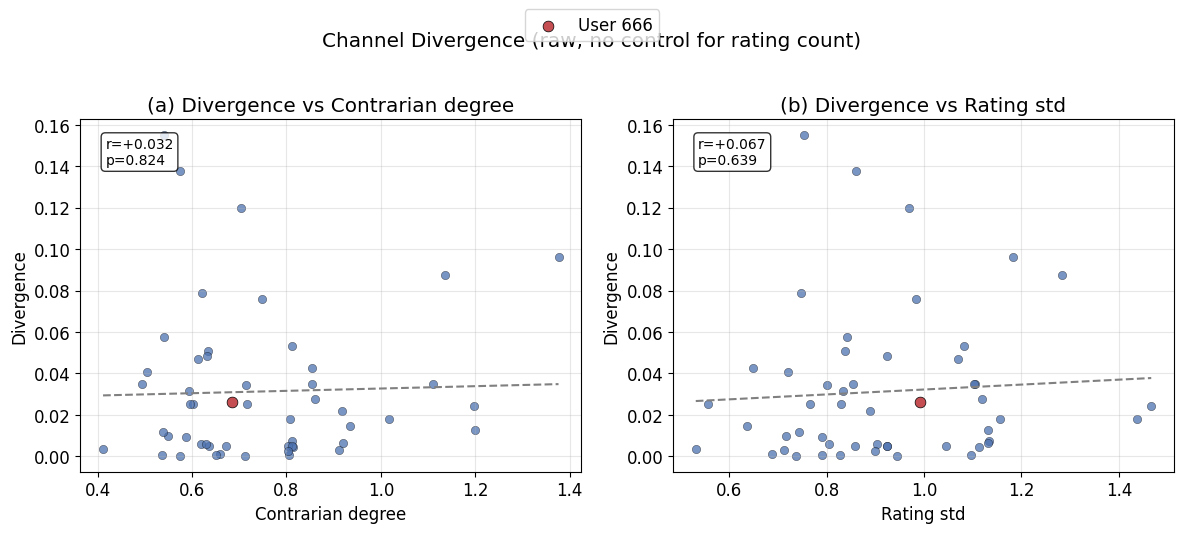

Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/divergence_raw.png


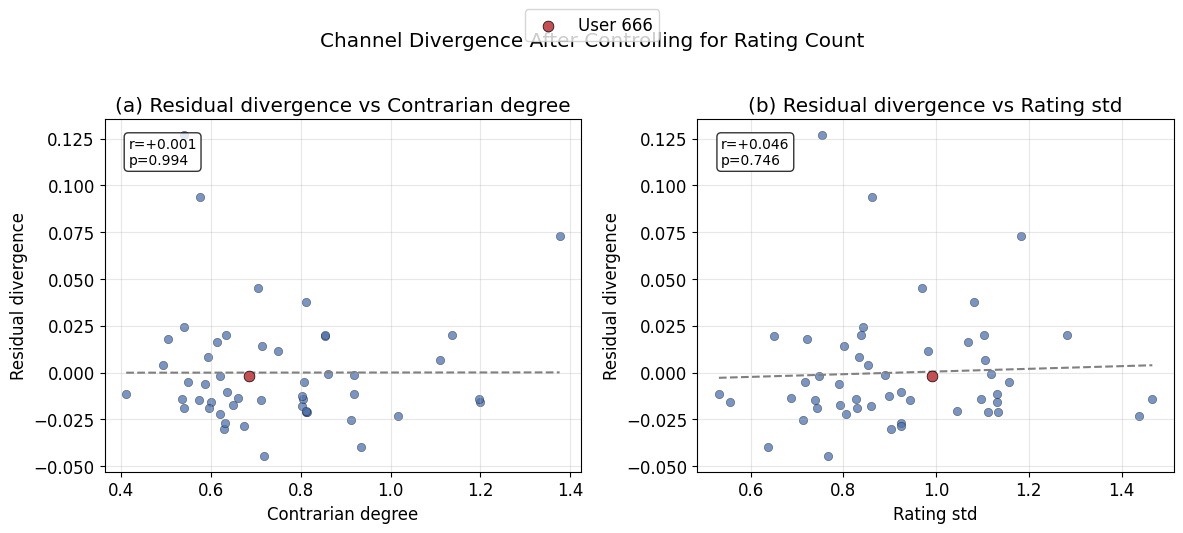

Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/divergence_controlled.png


In [ ]:
# Part 9 — Sparsity-Controlled Divergence Analysis
from scipy import stats

if "user_df" not in globals():
    raise RuntimeError("Run Part 8 first to create user_df.")

uid_highlight = 666


def partial_corr(x, y, control):
    """Partial Pearson r via residualization on control."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    control = np.asarray(control, dtype=float)
    n = len(x)
    resid_x = x - np.polyval(np.polyfit(control, x, 1), control)
    resid_y = y - np.polyval(np.polyfit(control, y, 1), control)
    r, _ = stats.pearsonr(resid_x, resid_y)
    df = n - 3
    t = r * np.sqrt(df / max(1e-12, 1.0 - r**2))
    p = 2.0 * stats.t.sf(abs(t), df)
    return float(r), float(p)


def plot_divergence_panels(df, y_col, ylabel, title, path):
    """Side-by-side scatter: divergence vs contrarian_degree / rating_std."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    panels = [
        ("contrarian_degree", "Contrarian degree", "(a)"),
        ("rating_std", "Rating std", "(b)"),
    ]
    for ax, (col, xlabel, plab) in zip(axes, panels):
        x = df[col].values
        y = df[y_col].values
        r, p = stats.pearsonr(x, y)
        mask_other = df["userId"] != uid_highlight
        ax.scatter(
            df.loc[mask_other, col],
            df.loc[mask_other, y_col],
            s=36,
            alpha=0.75,
            color="#4C72B0",
            edgecolors="k",
            linewidths=0.3,
        )
        ax.scatter(
            df.loc[~mask_other, col],
            df.loc[~mask_other, y_col],
            s=60,
            color="#C44E52",
            edgecolors="k",
            linewidths=0.5,
            zorder=5,
            label=f"User {uid_highlight}",
        )
        if len(x) > 1 and np.std(x) > 0:
            slope, intercept = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color="gray", lw=1.5, ls="--")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{plab} {ylabel} vs {xlabel}")
        ax.text(
            0.05,
            0.95,
            f"r={r:+.3f}\np={p:.3g}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=10,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        )
        ax.grid(alpha=0.3)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=1, bbox_to_anchor=(0.5, 1.08))
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


band_df = user_df.copy()

# ── Step A: partial correlations controlling for rating_count ─────────────────
print("=== Step A — Partial correlations (control: rating_count) ===")
partial_rows = []
for col, label in [
    ("contrarian_degree", "contrarian_degree"),
    ("rating_std", "rating_std"),
]:
    r, p = partial_corr(
        band_df["divergence"].values,
        band_df[col].values,
        band_df["rating_count"].values,
    )
    partial_rows.append({"pair": f"divergence vs {label}", "partial_r": r, "p-value": p})
    print(f"  divergence vs {label:18s}  partial r={r:+.4f}  p={p:.4g}")

partial_df = pd.DataFrame(partial_rows)

# ── Step B: tercile bands by rating_count ─────────────────────────────────────
print("\n=== Step B — Divergence vs contrarian_degree within rating_count terciles ===")
band_df["tercile"] = pd.qcut(band_df["rating_count"], 3, labels=["low", "mid", "high"])

band_rows = []
for label in ["low", "mid", "high"]:
    sub = band_df[band_df["tercile"] == label]
    r, p = stats.pearsonr(sub["divergence"], sub["contrarian_degree"])
    lo = int(sub["rating_count"].min())
    hi = int(sub["rating_count"].max())
    band_rows.append({
        "band": label,
        "rating_count_range": f"{lo}-{hi}",
        "n": len(sub),
        "r": r,
        "p-value": p,
    })
    print(f"  {label:4s} band  count {lo:3d}-{hi:3d}  n={len(sub):2d}  r={r:+.4f}  p={p:.4g}")

band_corr_df = pd.DataFrame(band_rows)

# ── Step C: residual divergence + raw vs controlled comparison ────────────────
beta = np.polyfit(band_df["rating_count"], band_df["divergence"], 1)
band_df["residual_divergence"] = band_df["divergence"] - np.polyval(
    beta, band_df["rating_count"]
)

print("\n=== Step C — Formulas & raw vs partial correlations ===")
print("divergence(u) = mean(|h1 - h2|) over hidden units")
print(
    f"residual_divergence = divergence - ({beta[0]:+.6f} * rating_count + {beta[1]:+.6f})"
)

print("\nRaw Pearson r (no control):")
for col in ["contrarian_degree", "rating_std", "rating_count"]:
    r, p = stats.pearsonr(band_df["divergence"], band_df[col])
    print(f"  divergence vs {col:18s}  r={r:+.4f}  p={p:.4g}")

u666 = band_df.loc[band_df["userId"] == uid_highlight].iloc[0]
print(f"\nUser {uid_highlight}:")
print(f"  divergence           = {u666['divergence']:.4f}")
print(f"  residual_divergence  = {u666['residual_divergence']:.4f}")
print(f"  rating_count         = {int(u666['rating_count'])}")

# ── Step D: raw figure (no control) ─────────────────────────────────────────
plot_divergence_panels(
    band_df,
    "divergence",
    "Divergence",
    "Channel Divergence (raw, no control for rating count)",
    out_dir / "divergence_raw.png",
)

# ── Step E: controlled figure (residual divergence) ───────────────────────────
plot_divergence_panels(
    band_df,
    "residual_divergence",
    "Residual divergence",
    "Channel Divergence After Controlling for Rating Count",
    out_dir / "divergence_controlled.png",
)